# Healthcare Predictive Analytics: Heart Disease Risk Screening

Engagement framing: A regional healthcare provider has asked us to develop a predictive analytics workflow that identifies patients with elevated likelihood of cardiovascular disease using routinely collected demographic, clinical, and lifestyle information.
This notebook is designed as a recruiter-ready portfolio project. It walks through business understanding, data understanding, cleaning, EDA, feature engineering, model development, evaluation, model interpretation, and portfolio storytelling.
Important clinical note: This is a portfolio analytics project, not a medical device. The model should be positioned as a decision-support or screening-prioritization tool, not as a standalone diagnostic system.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json
import math

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False

try:
    import shap
    SHAP_AVAILABLE = True
except Exception:
    SHAP_AVAILABLE = False

try:
    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.over_sampling import SMOTE
    IMBLEARN_AVAILABLE = True
except Exception:
    IMBLEARN_AVAILABLE = False

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid", palette="Set2")

RANDOM_STATE = 42

# Phase 1 - Business Understanding

Executive Summary
Cardiovascular disease remains one of the highest-impact drivers of mortality, avoidable hospital utilization, and long-term care cost. The healthcare provider wants to use routinely captured patient information such as age, blood pressure, cholesterol level, glucose level, smoking, alcohol use, physical activity, anthropometrics, occupation, country, and examination date to identify patients who may require closer cardiovascular risk review.
The goal of this engagement is to build an end-to-end predictive analytics workflow that estimates the likelihood of heart disease and explains the major risk factors associated with positive disease status. The final output should support earlier intervention, better population-health targeting, and more efficient clinical resource allocation.

# Business Problem
The provider needs a scalable way to prioritize patients for cardiovascular follow-up. Manual review of every patient is time-consuming, inconsistent, and difficult to scale across countries or care sites. A predictive model can help identify high-risk patient segments and the combinations of clinical and lifestyle factors most associated with disease.

# Stakeholders
Clinical leadership: Needs reliable screening insight without replacing physician judgment.
Primary care physicians and cardiologists: Need interpretable risk signals to guide follow-up.
Population health team: Needs patient segments for prevention campaigns and outreach.
Hospital operations leaders: Need to allocate screening, counseling, and referral capacity.
Data science and analytics team: Needs reproducible code, validated assumptions, and defensible metrics.
Compliance and governance teams: Need auditable preprocessing, ethical use, and clear limitations.

# Business Questions
Which patient characteristics are most associated with heart disease in this dataset?
Can routinely collected patient data predict disease status with useful screening performance?
Which model provides the best balance between recall, precision, interpretability, and operational usefulness?
Which patient groups appear to have elevated risk and may benefit from targeted prevention?
What data quality issues could affect clinical reliability?

# KPIs
Heart disease prevalence in the dataset.
Recall or sensitivity for disease-positive patients.
Specificity for disease-negative patients.
Precision or positive predictive value among flagged patients.
ROC-AUC for ranking quality.
F1-score for balance between precision and recall.
False negative rate, because missed disease cases are clinically costly.
High-risk segment size, which affects operational workload.

# Business Objectives
Build a reproducible healthcare ML workflow from raw data to model interpretation.
Create clinically meaningful features from vital signs and lifestyle variables.
Identify the model that best supports screening prioritization.
Communicate results in language usable by healthcare and analytics stakeholders.
Produce portfolio assets suitable for GitHub, LinkedIn, resume bullets, and interview discussion.

# Success Metrics
For a screening-oriented use case, the model should prioritize recall while maintaining reasonable precision. A strong portfolio result should include:
Transparent cleaning and validation logic.
Cross-validated model comparison.
Final holdout performance.
Confusion matrix and threshold analysis.
Interpretability analysis showing key drivers.
Clear limitations and ethical considerations.

# Healthcare Value
This project demonstrates how predictive analytics can support earlier cardiovascular risk detection, more targeted patient outreach, improved preventive-care planning, and better use of clinical resources. It also shows that you understand the difference between a predictive model and a clinically deployed diagnostic tool.

# Phase 2 - Data Understanding
The source data includes 70,000 patient examination records and 16 columns. The data dictionary is the source of truth for feature names and descriptions. A few dictionary entries are incomplete or inconsistent with the observed data, which is common in real-world projects and should be documented.

In [2]:
# Resolve paths robustly.
# Why: Jupyter may be launched from the project root or directly from the Dataset folder.

CURRENT_DIR = Path.cwd()

candidate_data_paths = [
    CURRENT_DIR / "Dataset" / "cardio_data.csv",
    CURRENT_DIR / "cardio_data.csv",
    CURRENT_DIR.parent / "Dataset" / "cardio_data.csv",
]

DATA_PATH = next((path for path in candidate_data_paths if path.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find cardio_data.csv. Put the notebook in the project folder "
        "or update DATA_PATH manually to the CSV location."
    )

PROJECT_ROOT = DATA_PATH.parent.parent if DATA_PATH.parent.name == "Dataset" else DATA_PATH.parent
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data path exists: {DATA_PATH.exists()} -> {DATA_PATH}")

Project root: C:\Users\HP\Documents\Project 3 - Healthcare - Predictive Analytics
Data path exists: True -> C:\Users\HP\Documents\Project 3 - Healthcare - Predictive Analytics\Dataset\cardio_data.csv


# Phase 3 - Data Cleaning
Healthcare preprocessing should be conservative and auditable.
Why:
Impossible clinical values can distort models and create unsafe conclusions.
Raw data should remain untouched.
Cleaning rules should be visible enough that a reviewer can challenge or approve them.
Derived clinical features must use documented assumptions.

In [4]:
# Load the raw dataset.
# Why: Always load raw data into a separate object so the original source remains unchanged.

raw_df = pd.read_csv(DATA_PATH)

print(f"Rows: {raw_df.shape[0]:,}")
print(f"Columns: {raw_df.shape[1]:,}")
display(raw_df.head())

Rows: 70,000
Columns: 16


,date,country,id,active,age,alco,ap_hi,ap_lo,cholesterol,gender,gluc,height,occupation,smoke,weight,disease
0,03-05-2021,Indonesia,0,1,18393,0,110,80,1,2,1,168,Architect,0,62.000,0
1,05-08-2021,Malaysia,1,1,20228,0,140,90,3,1,1,156,Accountant,0,85.000,1
2,13-11-2022,Indonesia,2,0,18857,0,130,70,3,1,1,165,Chef,0,64.000,1
3,31-10-2018,Singapore,3,1,17623,0,150,100,1,2,1,169,Lawyer,0,82.000,1
4,25-09-2020,Singapore,4,0,17474,0,100,60,1,1,1,156,Architect,0,56.000,0


In [5]:
# Inspect columns and data types.
# Why: Data types determine which cleaning, plotting, and modeling steps are appropriate.

display(pd.DataFrame({
    "column": raw_df.columns,
    "dtype": raw_df.dtypes.astype(str).values,
    "non_null_count": raw_df.notna().sum().values,
    "missing_count": raw_df.isna().sum().values,
    "missing_pct": (raw_df.isna().mean() * 100).round(2).values,
    "unique_values": raw_df.nunique(dropna=False).values,
}))

,column,dtype,non_null_count,missing_count,missing_pct,unique_values
0,date,str,70000,0,0.000,1827
1,country,str,70000,0,0.000,4
2,id,int64,70000,0,0.000,70000
3,active,int64,70000,0,0.000,2
4,age,int64,70000,0,0.000,8076
5,alco,int64,70000,0,0.000,2
6,ap_hi,int64,70000,0,0.000,153
7,ap_lo,int64,70000,0,0.000,157
8,cholesterol,int64,70000,0,0.000,3
9,gender,int64,70000,0,0.000,2


In [6]:
# Check duplicate rows and duplicate patient IDs.
# Why: Duplicate records can inflate model performance and bias prevalence estimates.

duplicate_rows = raw_df.duplicated().sum()
duplicate_ids = raw_df["id"].duplicated().sum()

print(f"Duplicate rows: {duplicate_rows:,}")
print(f"Duplicate patient IDs: {duplicate_ids:,}")

Duplicate rows: 0
Duplicate patient IDs: 0


In [7]:
# Inspect categorical/code fields.
# Why: Binary and ordinal fields should only contain valid expected codes.

code_columns = ["active", "alco", "cholesterol", "gender", "gluc", "smoke", "disease"]

for col in code_columns:
    print(f"\n{col}")
    display(raw_df[col].value_counts(dropna=False).sort_index().to_frame("count"))


active


,count
active,
0,13739
1,56261



alco


,count
alco,
0,66236
1,3764



cholesterol


...

,count
gluc,
1,59479
2,5190
3,5331



smoke


,count
smoke,
0,63831
1,6169



disease


,count
disease,
0,35021
1,34979


In [8]:
# Rename columns using professional healthcare analytics names.
# Why: Clear names make the notebook easier for recruiters, clinicians, and analysts to understand.

rename_map = {
    "date": "exam_date",
    "id": "patient_id",
    "active": "physically_active",
    "age": "age_days",
    "alco": "alcohol_use",
    "ap_hi": "systolic_bp",
    "ap_lo": "diastolic_bp",
    "cholesterol": "cholesterol_level",
    "gender": "gender_code",
    "gluc": "glucose_level",
    "height": "height_cm",
    "smoke": "smoking_status",
    "weight": "weight_kg",
    "disease": "heart_disease",
}

df = raw_df.rename(columns=rename_map).copy()
df.columns.tolist()

['exam_date',
 'country',
 'patient_id',
 'physically_active',
 'age_days',
 'alcohol_use',
 'systolic_bp',
 'diastolic_bp',
 'cholesterol_level',
 'gender_code',
 'glucose_level',
 'height_cm',
 'occupation',
 'smoking_status',
 'weight_kg',
 'heart_disease']

In [9]:
# Convert date and age fields.
# Why: Dates should be real datetime values, and age in days is not interpretable for clinical discussion.

df["exam_date"] = pd.to_datetime(df["exam_date"], format="%d-%m-%Y", errors="coerce")
df["age_years"] = (df["age_days"] / 365.25).round(1)
df["exam_year"] = df["exam_date"].dt.year
df["exam_month"] = df["exam_date"].dt.month

display(df[["exam_date", "age_days", "age_years", "exam_year", "exam_month"]].head())
print("Invalid dates:", df["exam_date"].isna().sum())
print("Exam date range:", df["exam_date"].min(), "to", df["exam_date"].max())

,exam_date,age_days,age_years,exam_year,exam_month
0,2021-05-03,18393,50.400,2021,5
1,2021-08-05,20228,55.400,2021,8
2,2022-11-13,18857,51.600,2022,11
3,2018-10-31,17623,48.200,2018,10
4,2020-09-25,17474,47.800,2020,9


Invalid dates: 0
Exam date range: 2018-01-01 00:00:00 to 2023-01-01 00:00:00


In [10]:
# Validate clinical ranges and create audit flags.
# Why: In healthcare, we should flag questionable values before removing or imputing them.

df["invalid_age_flag"] = ~df["age_years"].between(18, 100)
df["invalid_height_flag"] = ~df["height_cm"].between(120, 220)
df["invalid_weight_flag"] = ~df["weight_kg"].between(30, 250)
df["invalid_systolic_bp_flag"] = ~df["systolic_bp"].between(70, 250)
df["invalid_diastolic_bp_flag"] = ~df["diastolic_bp"].between(40, 150)
df["invalid_bp_relationship_flag"] = df["systolic_bp"] <= df["diastolic_bp"]

quality_flags = [
    "invalid_age_flag",
    "invalid_height_flag",
    "invalid_weight_flag",
    "invalid_systolic_bp_flag",
    "invalid_diastolic_bp_flag",
    "invalid_bp_relationship_flag",
]

quality_summary = (
    df[quality_flags]
    .sum()
    .rename("flagged_rows")
    .to_frame()
)
quality_summary["flagged_pct"] = (quality_summary["flagged_rows"] / len(df) * 100).round(3)
display(quality_summary)

,flagged_rows,flagged_pct
invalid_age_flag,0,0.000
invalid_height_flag,53,0.076
invalid_weight_flag,7,0.010
invalid_systolic_bp_flag,229,0.327
invalid_diastolic_bp_flag,1034,1.477
invalid_bp_relationship_flag,1236,1.766


In [11]:
# Replace impossible clinical values with missing values.
# Why: We should not winsorize impossible vital signs into believable values. Mark them missing and let the modeling pipeline impute or exclude as appropriate.

df_clean = df.copy()

df_clean.loc[df_clean["invalid_height_flag"], "height_cm"] = np.nan
df_clean.loc[df_clean["invalid_weight_flag"], "weight_kg"] = np.nan
df_clean.loc[
    df_clean["invalid_systolic_bp_flag"] | df_clean["invalid_bp_relationship_flag"],
    "systolic_bp",
] = np.nan
df_clean.loc[
    df_clean["invalid_diastolic_bp_flag"] | df_clean["invalid_bp_relationship_flag"],
    "diastolic_bp",
] = np.nan

display(df_clean[["systolic_bp", "diastolic_bp", "height_cm", "weight_kg"]].describe().T)

,count,mean,std,min,25%,50%,75%,max
systolic_bp,"68,718.000",126.675,16.696,70.000,120.000,120.000,140.000,240.000
diastolic_bp,"68,700.000",81.301,9.425,40.000,80.000,80.000,90.000,150.000
height_cm,"69,947.000",164.414,7.926,120.000,159.000,165.000,170.000,207.000
weight_kg,"69,993.000",74.211,14.386,30.000,65.000,72.000,82.000,200.000


In [12]:
# Standardize categorical variables.
# Why: Modeling pipelines need consistent categories, and portfolio readers need readable labels.

binary_map = {0: "No", 1: "Yes"}
level_map = {1: "Normal", 2: "Above Normal", 3: "High"}

df_clean["physically_active_label"] = df_clean["physically_active"].map(binary_map)
df_clean["alcohol_use_label"] = df_clean["alcohol_use"].map(binary_map)
df_clean["smoking_status_label"] = df_clean["smoking_status"].map(binary_map)
df_clean["heart_disease_label"] = df_clean["heart_disease"].map({0: "No Disease", 1: "Disease"})

# The data dictionary does not define the exact labels for gender codes.
# Keep these as codes unless you can verify the mapping from the source owner.
df_clean["gender_label"] = df_clean["gender_code"].map({1: "Gender Code 1", 2: "Gender Code 2"})

df_clean["cholesterol_category"] = df_clean["cholesterol_level"].map(level_map)
df_clean["glucose_category"] = df_clean["glucose_level"].map(level_map)

display(df_clean[[
    "physically_active_label",
    "alcohol_use_label",
    "smoking_status_label",
    "gender_label",
    "cholesterol_category",
    "glucose_category",
    "heart_disease_label",
]].head())

,physically_active_label,alcohol_use_label,smoking_status_label,gender_label,cholesterol_category,glucose_category,heart_disease_label
0,Yes,No,No,Gender Code 2,Normal,Normal,No Disease
1,Yes,No,No,Gender Code 1,High,Normal,Disease
2,No,No,No,Gender Code 1,High,Normal,Disease
3,Yes,No,No,Gender Code 2,Normal,Normal,Disease
4,No,No,No,Gender Code 1,Normal,Normal,No Disease


In [13]:
# Create derived clinical features.
# Why: Raw variables are useful, but clinically meaningful features often improve signal and interpretability.

df_clean["bmi"] = df_clean["weight_kg"] / ((df_clean["height_cm"] / 100) ** 2)
df_clean.loc[~df_clean["bmi"].between(10, 80), "bmi"] = np.nan

df_clean["age_group"] = pd.cut(
    df_clean["age_years"],
    bins=[0, 40, 50, 60, 70, 120],
    labels=["<40", "40-49", "50-59", "60-69", "70+"],
    right=False,
)

def classify_bp(row):
    sbp = row["systolic_bp"]
    dbp = row["diastolic_bp"]
    if pd.isna(sbp) or pd.isna(dbp):
        return np.nan
    if sbp >= 180 or dbp >= 120:
        return "Hypertensive Crisis"
    if sbp >= 140 or dbp >= 90:
        return "Hypertension Stage 2"
    if 130 <= sbp < 140 or 80 <= dbp < 90:
        return "Hypertension Stage 1"
    if 120 <= sbp < 130 and dbp < 80:
        return "Elevated"
    return "Normal"

df_clean["bp_category"] = df_clean.apply(classify_bp, axis=1)

df_clean["bmi_category"] = pd.cut(
    df_clean["bmi"],
    bins=[0, 18.5, 25, 30, 35, 40, np.inf],
    labels=["Underweight", "Normal", "Overweight", "Obesity I", "Obesity II", "Obesity III"],
    right=False,
)

df_clean["high_cholesterol_flag"] = (df_clean["cholesterol_level"] >= 2).astype(int)
df_clean["high_glucose_flag"] = (df_clean["glucose_level"] >= 2).astype(int)
df_clean["hypertension_flag"] = df_clean["bp_category"].isin([
    "Hypertension Stage 1",
    "Hypertension Stage 2",
    "Hypertensive Crisis",
]).astype(int)
df_clean["obesity_flag"] = (df_clean["bmi"] >= 30).astype(int)
df_clean["inactive_flag"] = (df_clean["physically_active"] == 0).astype(int)

df_clean["lifestyle_risk_score"] = (
    df_clean["smoking_status"] + df_clean["alcohol_use"] + df_clean["inactive_flag"]
)

df_clean["clinical_risk_factor_count"] = (
    df_clean["high_cholesterol_flag"]
    + df_clean["high_glucose_flag"]
    + df_clean["hypertension_flag"]
    + df_clean["obesity_flag"]
    + df_clean["smoking_status"]
)

df_clean["age_bp_interaction"] = df_clean["age_years"] * df_clean["hypertension_flag"]
df_clean["obesity_bp_interaction"] = df_clean["obesity_flag"] * df_clean["hypertension_flag"]

display(df_clean[[
    "age_years",
    "age_group",
    "systolic_bp",
    "diastolic_bp",
    "bp_category",
    "bmi",
    "bmi_category",
    "lifestyle_risk_score",
    "clinical_risk_factor_count",
]].head())

,age_years,age_group,systolic_bp,diastolic_bp,bp_category,bmi,bmi_category,lifestyle_risk_score,clinical_risk_factor_count
0,50.400,50-59,110.000,80.000,Hypertension Stage 1,21.967,Normal,0,1
1,55.400,50-59,140.000,90.000,Hypertension Stage 2,34.928,Obesity I,0,3
2,51.600,50-59,130.000,70.000,Hypertension Stage 1,23.508,Normal,1,2
3,48.200,40-49,150.000,100.000,Hypertension Stage 2,28.710,Overweight,0,1
4,47.800,40-49,100.000,60.000,Normal,23.011,Normal,1,0


In [14]:
# Validate the cleaned dataset.
# Why: Cleaning is not complete until we prove key assumptions still hold.

validation_checks = {
    "rows_raw": len(raw_df),
    "rows_clean": len(df_clean),
    "duplicate_patient_ids": int(df_clean["patient_id"].duplicated().sum()),
    "missing_exam_date": int(df_clean["exam_date"].isna().sum()),
    "missing_systolic_bp_after_cleaning": int(df_clean["systolic_bp"].isna().sum()),
    "missing_diastolic_bp_after_cleaning": int(df_clean["diastolic_bp"].isna().sum()),
    "missing_bmi_after_cleaning": int(df_clean["bmi"].isna().sum()),
    "target_positive_rate": float(df_clean["heart_disease"].mean()),
}

print(json.dumps(validation_checks, indent=2))

cleaned_path = OUTPUT_DIR / "cardio_data_cleaned_featured.csv"
df_clean.to_csv(cleaned_path, index=False)
print(f"Saved cleaned/featured dataset to: {cleaned_path}")

{
  "rows_raw": 70000,
  "rows_clean": 70000,
  "duplicate_patient_ids": 0,
  "missing_exam_date": 0,
  "missing_systolic_bp_after_cleaning": 1282,
  "missing_diastolic_bp_after_cleaning": 1300,
  "missing_bmi_after_cleaning": 63,
  "target_positive_rate": 0.4997
}
Saved cleaned/featured dataset to: C:\Users\HP\Documents\Project 3 - Healthcare - Predictive Analytics\outputs\cardio_data_cleaned_featured.csv


# Phase 4 - Exploratory Data Analysis
EDA should answer business and clinical questions, not just produce charts.
Recommended chart choices:
Bar chart: target distribution and categorical risk factors.
Histogram/KDE: age, BMI, blood pressure distributions.
Box plot or violin plot: numeric risk factors by disease status.
Stacked percentage bar: disease rate by category.
Heatmap: correlation among numeric and ordinal variables.
Point plot: disease rate across ordered clinical categories.
The goal is to convert patterns into clinical hypotheses and modeling decisions.

,count,percent
heart_disease_label,,
No Disease,35021,50.030
Disease,34979,49.970


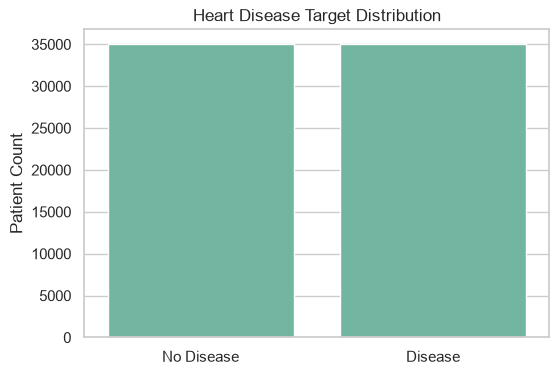

In [15]:
# Target distribution.
# Why: Class balance affects model choice, evaluation metrics, and threshold strategy.

target_counts = df_clean["heart_disease_label"].value_counts()
target_rates = df_clean["heart_disease_label"].value_counts(normalize=True).mul(100).round(2)

display(pd.DataFrame({"count": target_counts, "percent": target_rates}))

plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x="heart_disease_label", order=["No Disease", "Disease"])
plt.title("Heart Disease Target Distribution")
plt.xlabel("")
plt.ylabel("Patient Count")
plt.show()

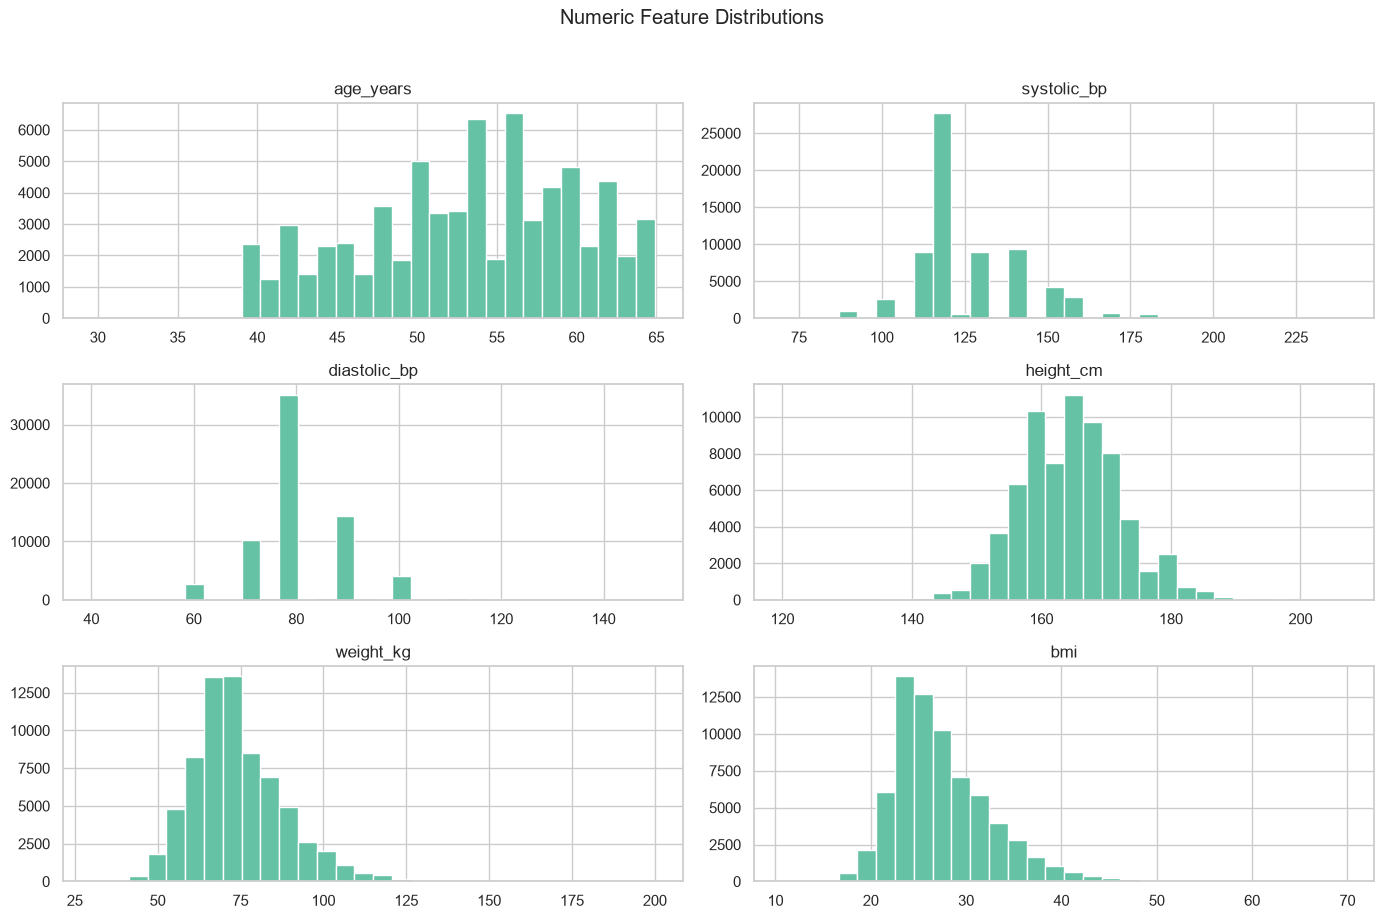

,count,mean,std,min,1%,5%,50%,95%,99%,max
age_years,"70,000.000",53.303,6.755,29.600,39.600,41.300,53.900,63.700,64.300,64.900
systolic_bp,"68,718.000",126.675,16.696,70.000,90.000,100.000,120.000,160.000,180.000,240.000
diastolic_bp,"68,700.000",81.301,9.425,40.000,60.000,70.000,80.000,100.000,100.000,150.000
height_cm,"69,947.000",164.414,7.926,120.000,147.000,152.000,165.000,178.000,184.000,207.000
weight_kg,"69,993.000",74.211,14.386,30.000,48.000,55.000,72.000,100.000,117.000,200.000
bmi,"69,937.000",27.487,5.259,10.727,18.612,20.937,26.370,37.324,44.072,69.828


In [16]:
# Univariate analysis for numeric clinical variables.
# Why: Distributions reveal skew, outliers, and whether transformations may be useful.

numeric_eda_cols = ["age_years", "systolic_bp", "diastolic_bp", "height_cm", "weight_kg", "bmi"]

df_clean[numeric_eda_cols].hist(figsize=(14, 9), bins=30)
plt.suptitle("Numeric Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

display(df_clean[numeric_eda_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T)

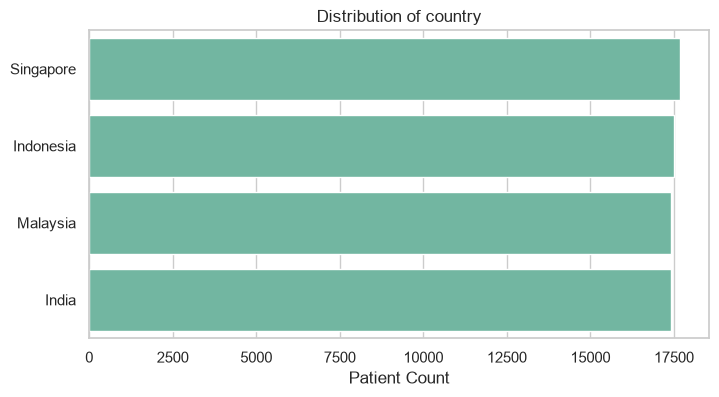

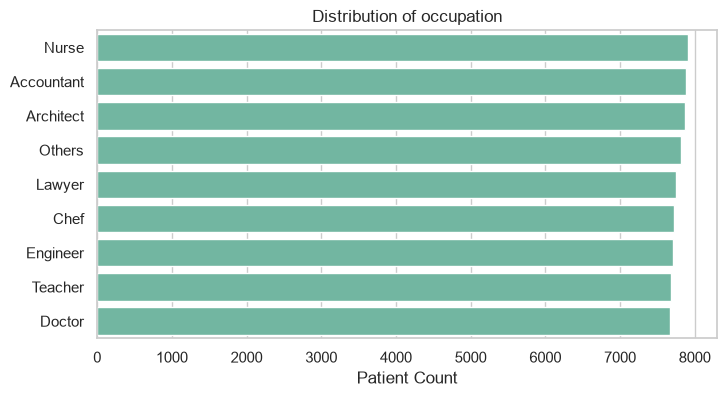

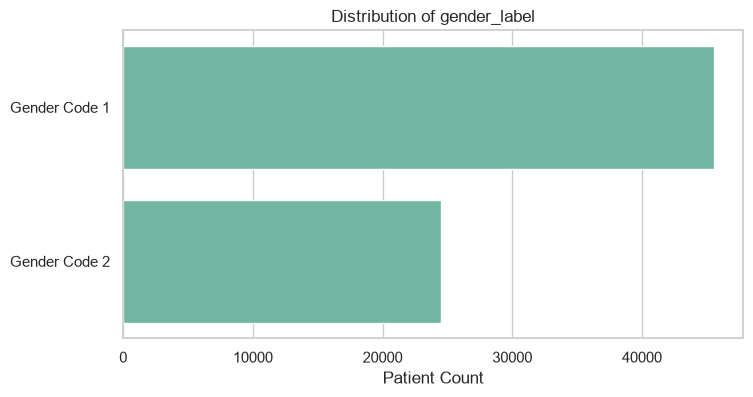

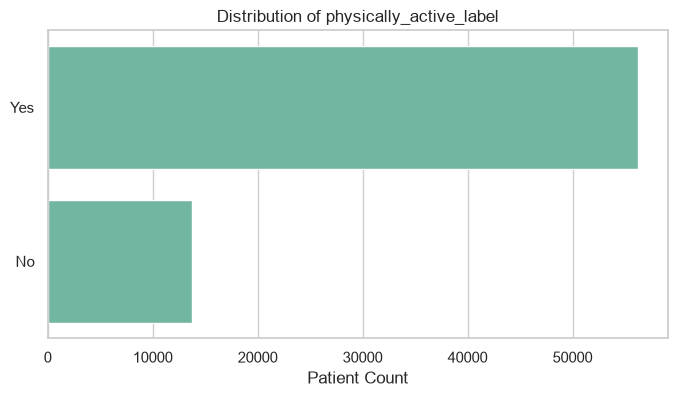

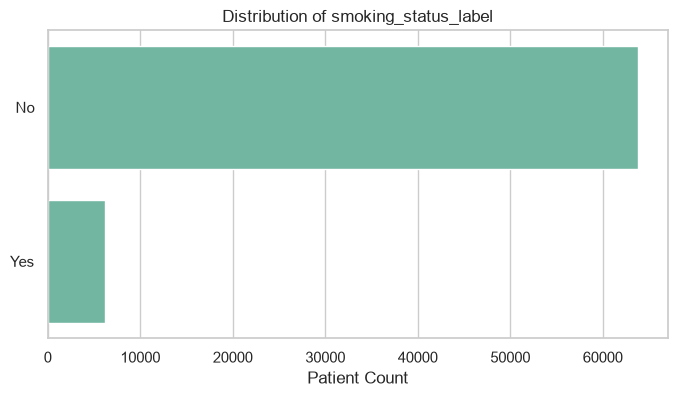

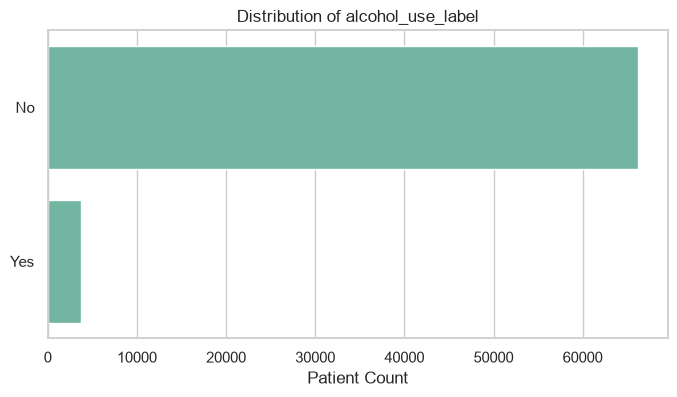

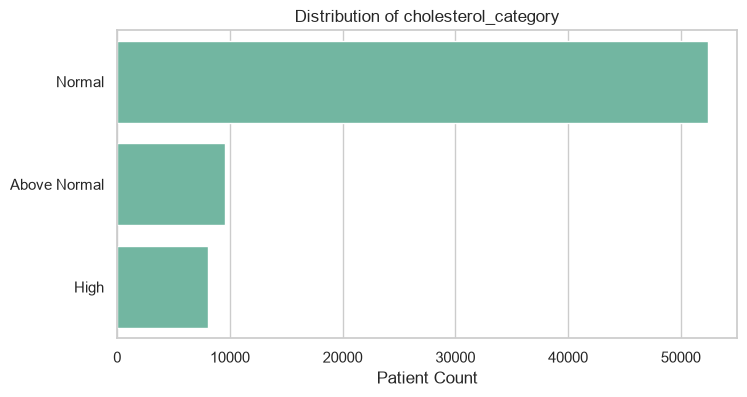

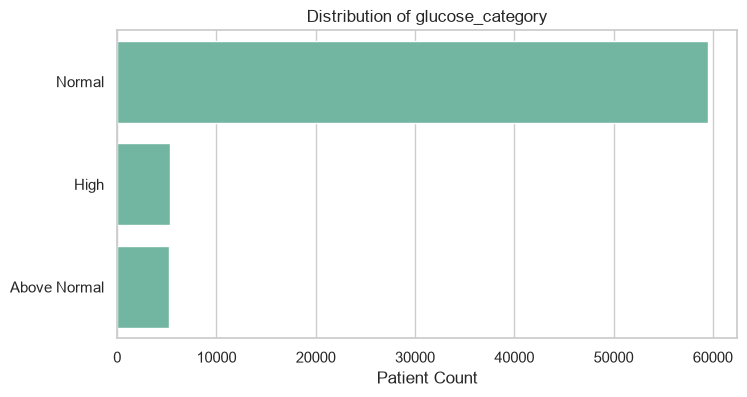

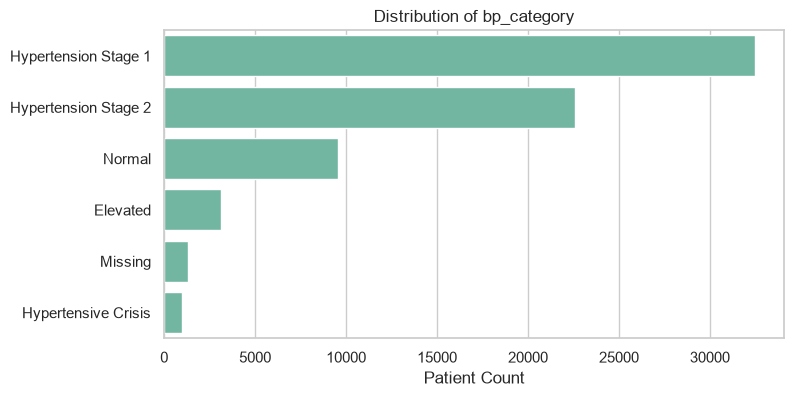

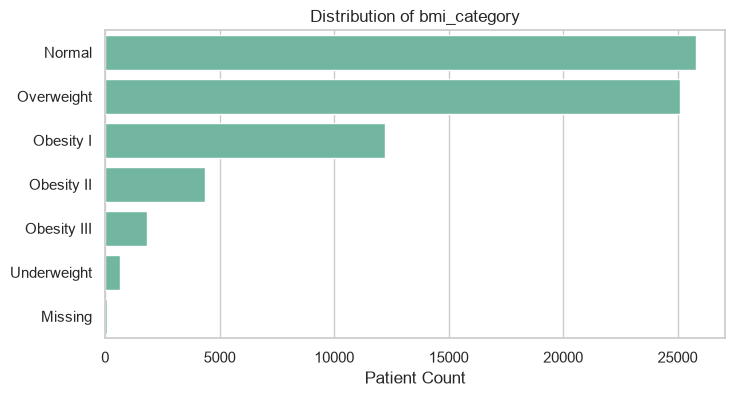

In [18]:
# Categorical feature distributions.
# Why: Category frequency affects feature reliability and model stability.

categorical_eda_cols = [
    "country",
    "occupation",
    "gender_label",
    "physically_active_label",
    "smoking_status_label",
    "alcohol_use_label",
    "cholesterol_category",
    "glucose_category",
    "bp_category",
    "bmi_category",
]

for col in categorical_eda_cols:
    plot_data = df_clean[[col]].copy()
    plot_data[col] = plot_data[col].astype("object").where(plot_data[col].notna(), "Missing").astype(str)

    plt.figure(figsize=(8, 4))
    order = plot_data[col].value_counts().index
    sns.countplot(data=plot_data, y=col, order=order)
    plt.title(f"Distribution of {col}")
    plt.xlabel("Patient Count")
    plt.ylabel("")
    plt.show()

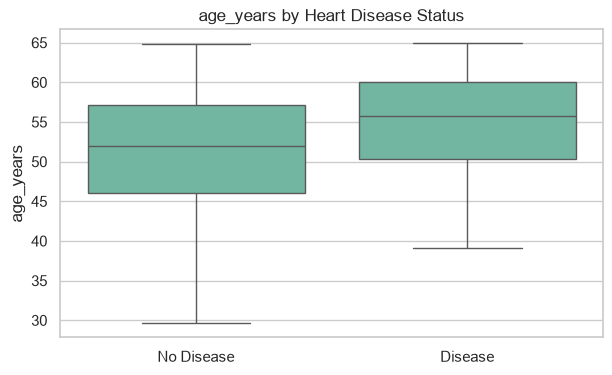

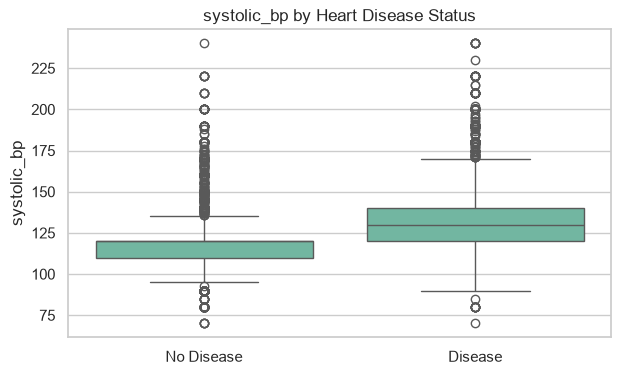

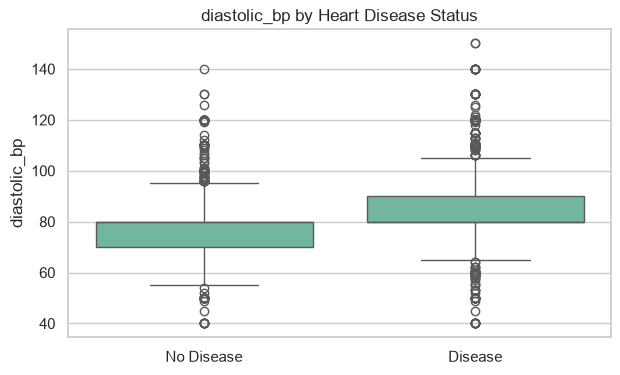

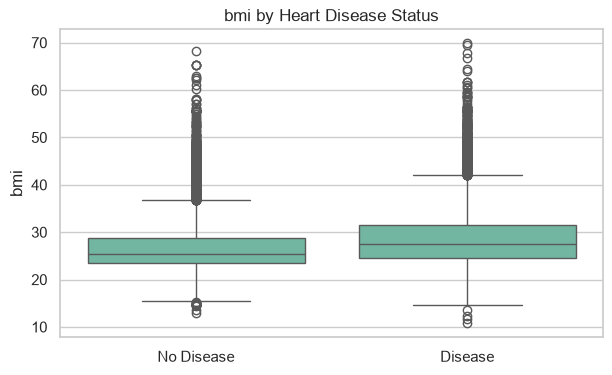

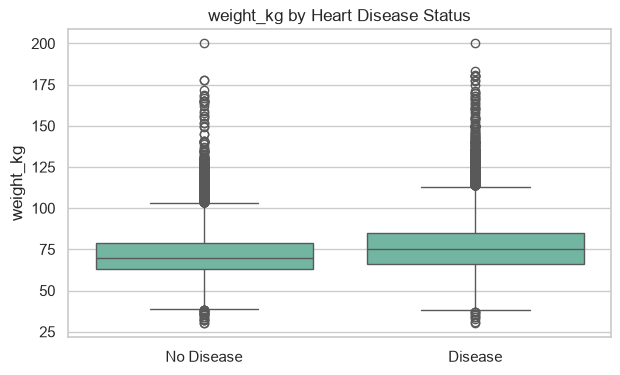

,age_years,systolic_bp,diastolic_bp,bmi
heart_disease_label,,,,
Disease,54.913,133.895,84.546,28.497
No Disease,51.695,119.607,78.122,26.479


In [19]:
# Bivariate analysis: numeric features by disease status.
# Why: These plots show how clinical measurements differ between disease-positive and disease-negative patients.

for col in ["age_years", "systolic_bp", "diastolic_bp", "bmi", "weight_kg"]:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df_clean, x="heart_disease_label", y=col, order=["No Disease", "Disease"])
    plt.title(f"{col} by Heart Disease Status")
    plt.xlabel("")
    plt.ylabel(col)
    plt.show()

group_summary = df_clean.groupby("heart_disease_label")[["age_years", "systolic_bp", "diastolic_bp", "bmi"]].mean()
display(group_summary)

,age_group,patients,disease_rate,disease_rate_pct
2,60-69,13099,0.670,67.000
1,50-59,35578,0.516,51.600
0,40-49,19619,0.378,37.850
3,<40,1704,0.245,24.530


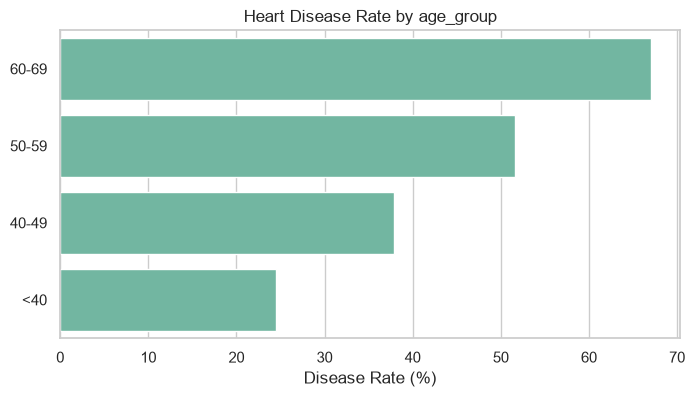

,bp_category,patients,disease_rate,disease_rate_pct
3,Hypertensive Crisis,975,0.866,86.560
2,Hypertension Stage 2,22567,0.776,77.640
4,Missing,1334,0.757,75.710
1,Hypertension Stage 1,32460,0.385,38.450
0,Elevated,3109,0.323,32.290
5,Normal,9555,0.222,22.160


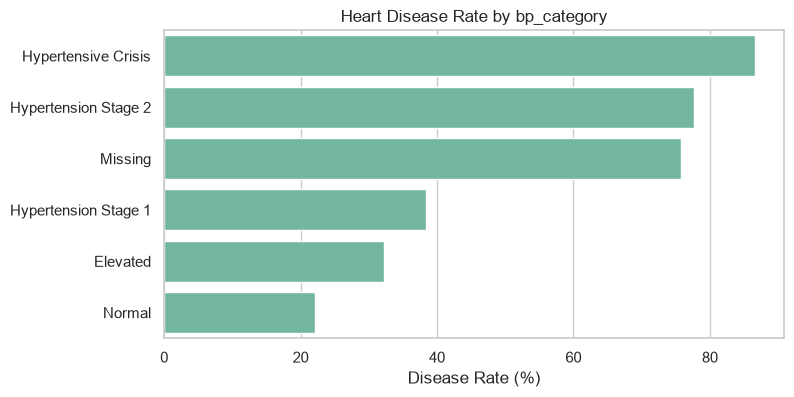

,cholesterol_category,patients,disease_rate,disease_rate_pct
1,High,8066,0.765,76.540
0,Above Normal,9549,0.602,60.220
2,Normal,52385,0.440,44.010


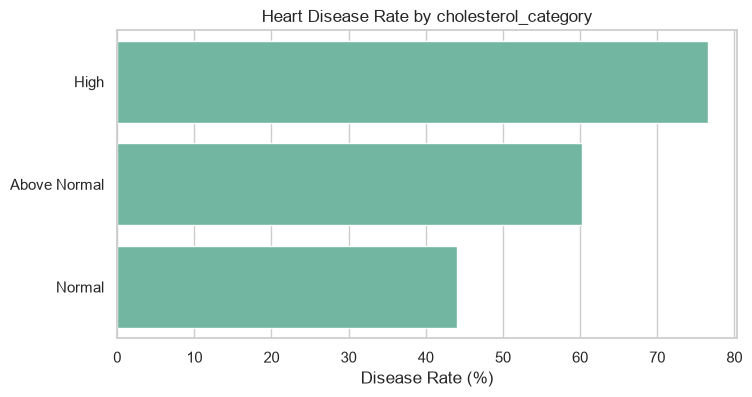

,glucose_category,patients,disease_rate,disease_rate_pct
1,High,5331,0.622,62.200
0,Above Normal,5190,0.593,59.310
2,Normal,59479,0.481,48.060


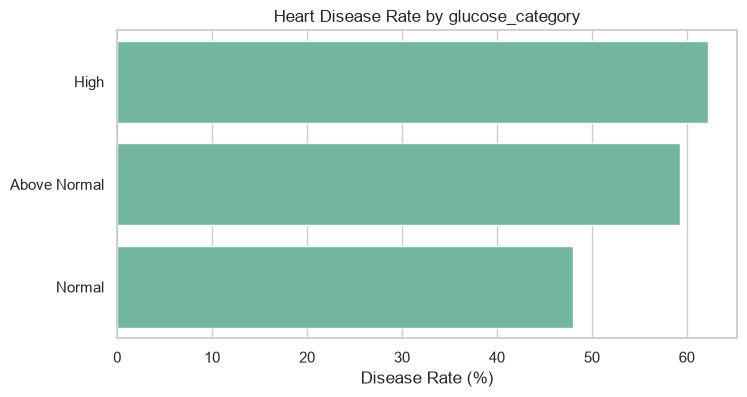

,bmi_category,patients,disease_rate,disease_rate_pct
4,Obesity III,1831,0.694,69.420
3,Obesity II,4376,0.680,67.960
2,Obesity I,12212,0.604,60.420
0,Missing,63,0.524,52.380
5,Overweight,25086,0.510,51.010
1,Normal,25790,0.401,40.130
6,Underweight,642,0.276,27.570


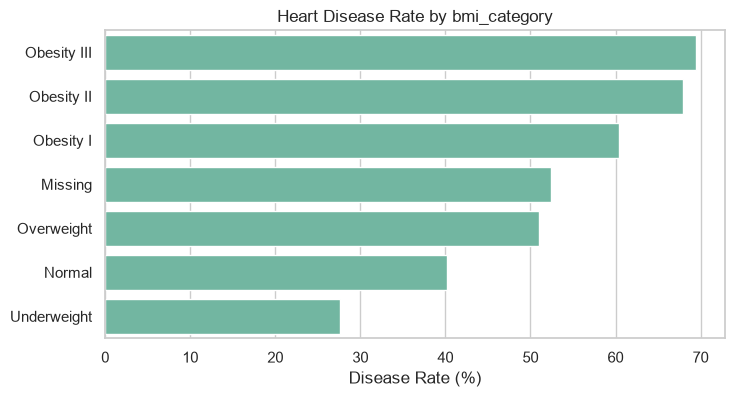

,smoking_status_label,patients,disease_rate,disease_rate_pct
0,No,63831,0.502,50.210
1,Yes,6169,0.475,47.480


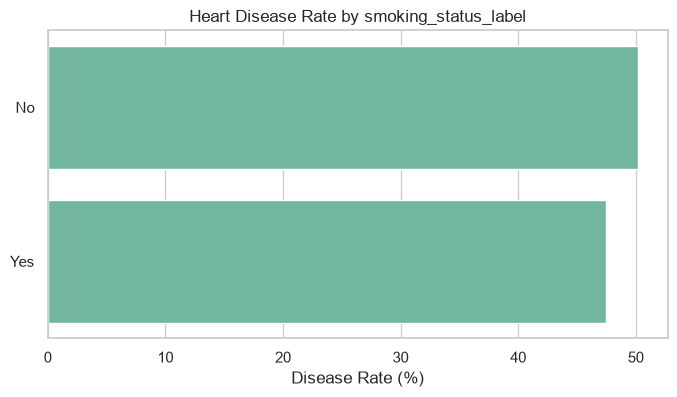

,physically_active_label,patients,disease_rate,disease_rate_pct
0,No,13739,0.536,53.580
1,Yes,56261,0.491,49.090


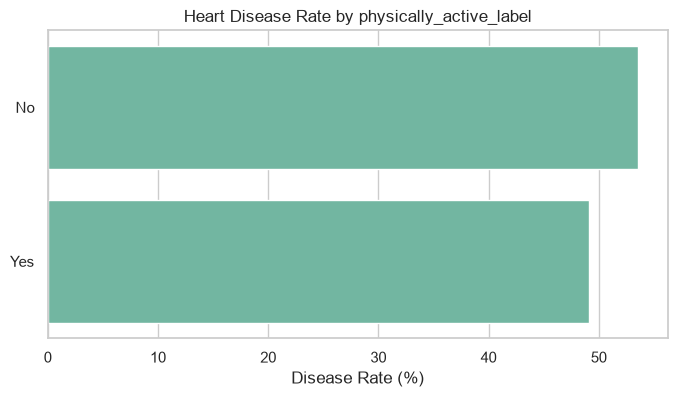

In [20]:
# Disease rate by categorical risk factors.
# Why: Disease rates are more clinically interpretable than raw category counts.

def disease_rate_table(data, col):
    temp = data[[col, "heart_disease"]].copy()
    temp[col] = temp[col].astype("object").where(temp[col].notna(), "Missing").astype(str)

    out = (
        temp.groupby(col, dropna=False)
        .agg(
            patients=("heart_disease", "size"),
            disease_rate=("heart_disease", "mean"),
        )
        .reset_index()
    )
    out["disease_rate_pct"] = (out["disease_rate"] * 100).round(2)
    return out.sort_values("disease_rate", ascending=False)

for col in ["age_group", "bp_category", "cholesterol_category", "glucose_category", "bmi_category", "smoking_status_label", "physically_active_label"]:
    rates = disease_rate_table(df_clean, col)
    display(rates)
    plt.figure(figsize=(8, 4))
    sns.barplot(data=rates, y=col, x="disease_rate_pct")
    plt.title(f"Heart Disease Rate by {col}")
    plt.xlabel("Disease Rate (%)")
    plt.ylabel("")
    plt.show()

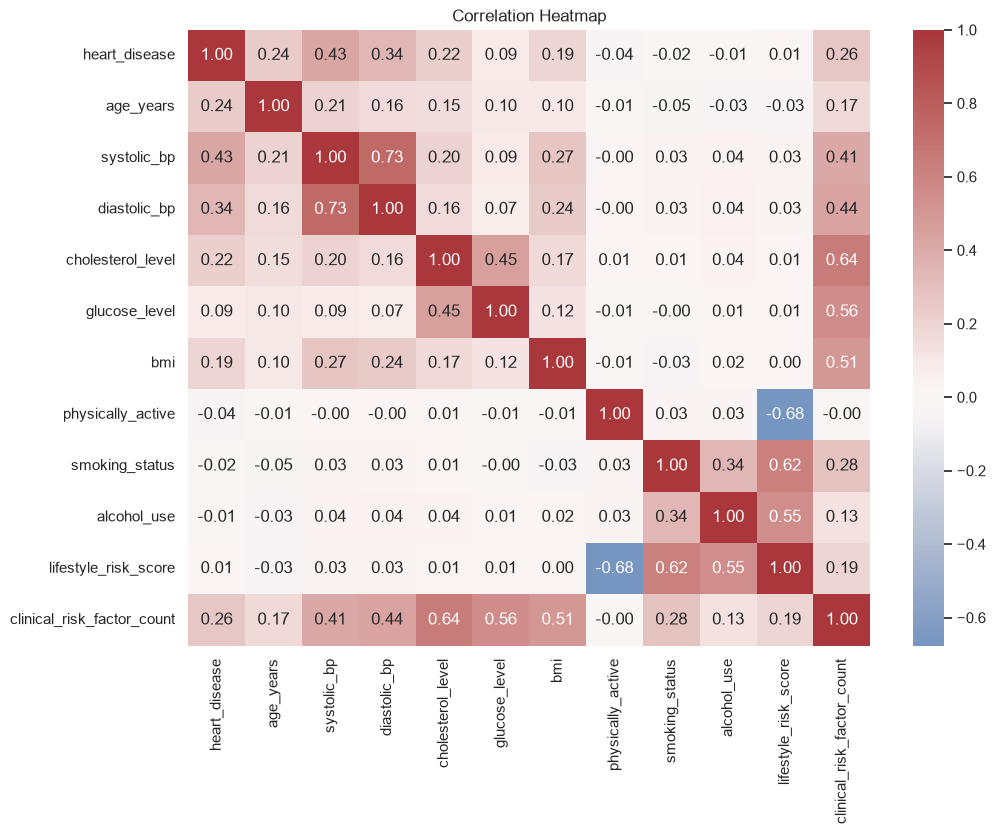

,correlation_with_target
heart_disease,1.000
systolic_bp,0.428
diastolic_bp,0.341
clinical_risk_factor_count,0.263
age_years,0.238
cholesterol_level,0.221
bmi,0.192
glucose_level,0.089
lifestyle_risk_score,0.014
alcohol_use,-0.007


In [21]:
# Correlation analysis.
# Why: Correlation helps identify related risk factors and potential multicollinearity.

corr_cols = [
    "heart_disease",
    "age_years",
    "systolic_bp",
    "diastolic_bp",
    "cholesterol_level",
    "glucose_level",
    "bmi",
    "physically_active",
    "smoking_status",
    "alcohol_use",
    "lifestyle_risk_score",
    "clinical_risk_factor_count",
]

corr = df_clean[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlation Heatmap")
plt.show()

display(corr["heart_disease"].sort_values(ascending=False).to_frame("correlation_with_target"))

# Phase 5 - Feature Engineering

In [22]:
# Modeling dataset preparation.
# Why: Exclude IDs and label-only columns, keep target separate, and avoid leakage.

model_df = df_clean.copy()

target = "heart_disease"

numeric_features = [
    "age_years",
    "systolic_bp",
    "diastolic_bp",
    "height_cm",
    "weight_kg",
    "bmi",
    "lifestyle_risk_score",
    "clinical_risk_factor_count",
    "age_bp_interaction",
    "obesity_bp_interaction",
]

ordinal_features = [
    "cholesterol_level",
    "glucose_level",
]

binary_features = [
    "physically_active",
    "alcohol_use",
    "smoking_status",
    "high_cholesterol_flag",
    "high_glucose_flag",
    "hypertension_flag",
    "obesity_flag",
    "inactive_flag",
]

categorical_features = [
    "country",
    "occupation",
    "gender_code",
    "age_group",
    "bp_category",
    "bmi_category",
    "exam_year",
    "exam_month",
]

feature_cols = numeric_features + ordinal_features + binary_features + categorical_features

X = model_df[feature_cols]
y = model_df[target]

print(f"Modeling rows: {len(X):,}")
print(f"Feature count before encoding: {len(feature_cols)}")
display(X.head())

Modeling rows: 70,000
Feature count before encoding: 28


,age_years,systolic_bp,diastolic_bp,height_cm,weight_kg,bmi,lifestyle_risk_score,clinical_risk_factor_count,age_bp_interaction,obesity_bp_interaction,cholesterol_level,glucose_level,physically_active,alcohol_use,smoking_status,high_cholesterol_flag,high_glucose_flag,hypertension_flag,obesity_flag,inactive_flag,country,occupation,gender_code,age_group,bp_category,bmi_category,exam_year,exam_month
0,50.400,110.000,80.000,168.000,62.000,21.967,0,1,50.400,0,1,1,1,0,0,0,0,1,0,0,Indonesia,Architect,2,50-59,Hypertension Stage 1,Normal,2021,5
1,55.400,140.000,90.000,156.000,85.000,34.928,0,3,55.400,1,3,1,1,0,0,1,0,1,1,0,Malaysia,Accountant,1,50-59,Hypertension Stage 2,Obesity I,2021,8
2,51.600,130.000,70.000,165.000,64.000,23.508,1,2,51.600,0,3,1,0,0,0,1,0,1,0,1,Indonesia,Chef,1,50-59,Hypertension Stage 1,Normal,2022,11
3,48.200,150.000,100.000,169.000,82.000,28.710,0,1,48.200,0,1,1,1,0,0,0,0,1,0,0,Singapore,Lawyer,2,40-49,Hypertension Stage 2,Overweight,2018,10
4,47.800,100.000,60.000,156.000,56.000,23.011,1,0,0.000,0,1,1,0,0,0,0,0,0,0,1,Singapore,Architect,1,40-49,Normal,Normal,2020,9


# Phase 6 - Model Building

In [23]:
# Train-test split.
# Why: The holdout test set estimates performance on unseen patients.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train target rate:", y_train.mean().round(4))
print("Test target rate:", y_test.mean().round(4))

Train target rate: 0.4997
Test target rate: 0.4997


In [24]:
# Preprocessing pipeline.
# Why: Numeric, binary, ordinal, and categorical fields need different preprocessing.

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

ordinal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
])

binary_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
])

try:
    onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehot_encoder),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("ord", ordinal_transformer, ordinal_features),
        ("bin", binary_transformer, binary_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

In [25]:
# Define candidate models.
# Why: A professional project compares multiple reasonable algorithms before selecting a final model.

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, min_samples_leaf=100, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=250,
        max_depth=None,
        min_samples_leaf=30,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "SVM": SVC(kernel="rbf", C=1.0, probability=True, class_weight="balanced", random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(n_neighbors=25),
}

if XGBOOST_AVAILABLE:
    models["XGBoost"] = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.85,
        colsample_bytree=0.85,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
    )
else:
    print("XGBoost is not installed. Install xgboost if you want to include it.")

list(models.keys())

['Logistic Regression',
 'Decision Tree',
 'Random Forest',
 'Gradient Boosting',
 'SVM',
 'KNN',
 'XGBoost']

# Cross-validation model comparison.
# Why: Cross-validation provides a more stable estimate than a single split.

# SVM and KNN can be slow on 70,000 rows. Use a sample for early experimentation, then set to None for final runs.
BENCHMARK_SAMPLE_SIZE = 20000  # set to None to use all training rows

if BENCHMARK_SAMPLE_SIZE is not None and len(X_train) > BENCHMARK_SAMPLE_SIZE:
    X_cv = X_train.sample(BENCHMARK_SAMPLE_SIZE, random_state=RANDOM_STATE)
    y_cv = y_train.loc[X_cv.index]
else:
    X_cv = X_train
    y_cv = y_train

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = []

for name, estimator in models.items():
    print(f"Training {name}...")
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", estimator),
    ])
    cv_scores = cross_validate(
        pipe,
        X_cv,
        y_cv,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        error_score="raise",
    )
    row = {"model": name}
    for metric in scoring:
        row[f"{metric}_mean"] = cv_scores[f"test_{metric}"].mean()
        row[f"{metric}_std"] = cv_scores[f"test_{metric}"].std()
    results.append(row)

comparison_df = pd.DataFrame(results).sort_values(
    by=["recall_mean", "roc_auc_mean", "f1_mean"],
    ascending=False,
)

display(comparison_df)

In [27]:
# Hyperparameter tuning for the strongest practical candidate.
# Why: After broad model comparison, tune the most promising model instead of randomly tweaking many models.

tuned_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE)),
])

param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [8, 14, None],
    "model__min_samples_leaf": [20, 50],
}

grid = GridSearchCV(
    tuned_rf,
    param_grid=param_grid,
    scoring="recall",
    cv=3,
    n_jobs=-1,
    verbose=1,
)

# To save time during development, you can tune on a sample first.
TUNING_SAMPLE_SIZE = 30000  # set to None for full training data
if TUNING_SAMPLE_SIZE is not None and len(X_train) > TUNING_SAMPLE_SIZE:
    X_tune = X_train.sample(TUNING_SAMPLE_SIZE, random_state=RANDOM_STATE)
    y_tune = y_train.loc[X_tune.index]
else:
    X_tune = X_train
    y_tune = y_train

grid.fit(X_tune, y_tune)

print("Best parameters:", grid.best_params_)
print("Best CV recall:", round(grid.best_score_, 4))

best_model = grid.best_estimator_

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters: {'model__max_depth': None, 'model__min_samples_leaf': 20, 'model__n_estimators': 200}
Best CV recall: 0.6983


In [28]:
# Optional class imbalance workflow.
# Why: If disease prevalence were low, SMOTE or class-weighting could help recall. Here, class balance is nearly even, so this is optional.

class_balance = y_train.value_counts(normalize=True).rename("train_rate")
display(class_balance)

if IMBLEARN_AVAILABLE:
    smote_lr = ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ])
    smote_scores = cross_validate(
        smote_lr,
        X_cv,
        y_cv,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
    )
    print("SMOTE Logistic Regression CV recall:", round(smote_scores["test_recall"].mean(), 4))
else:
    print("imbalanced-learn is not installed. This is acceptable because the target is nearly balanced.")

heart_disease
0   0.500
1   0.500
Name: train_rate, dtype: float64

SMOTE Logistic Regression CV recall: 0.6711


# Phase 7 - Evaluation
For healthcare classification, the evaluation must reflect clinical risk.
Key metrics:
Accuracy: Overall correctness. Useful here because classes are balanced, but not enough by itself.
Precision: Among patients flagged positive, the percent truly positive. Important for workload and unnecessary follow-up.
Recall / Sensitivity: Among true disease-positive patients, the percent caught by the model. Usually prioritized for screening.
Specificity: Among true disease-negative patients, the percent correctly not flagged.
F1-score: Balance between precision and recall.
ROC-AUC: Ability to rank positives above negatives across thresholds.
Confusion matrix: Shows false positives and false negatives directly.
Threshold analysis: Lets the provider choose the operating point based on clinical capacity and risk tolerance.
For disease screening, recall is often prioritized because false negatives mean potentially missing patients who need care. Precision still matters because too many false positives can overwhelm clinics.

In [29]:
# Fit the selected model on the full training set and evaluate on the holdout test set.
# Why: The test set should only be used once for final unbiased evaluation.

best_model.fit(X_train, y_train)

y_pred_default = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

def evaluate_predictions(y_true, y_pred, y_score=None):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp)
    output = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall_sensitivity": recall_score(y_true, y_pred),
        "specificity": specificity,
        "f1": f1_score(y_true, y_pred),
        "false_negative_rate": fn / (fn + tp),
        "false_positive_rate": fp / (fp + tn),
    }
    if y_score is not None:
        output["roc_auc"] = roc_auc_score(y_true, y_score)
    return pd.Series(output)

final_metrics = evaluate_predictions(y_test, y_pred_default, y_proba)
display(final_metrics.to_frame("holdout_metric"))

print(classification_report(y_test, y_pred_default, target_names=["No Disease", "Disease"]))

,holdout_metric
accuracy,0.732
precision,0.749
recall_sensitivity,0.698
specificity,0.767
f1,0.723
false_negative_rate,0.302
false_positive_rate,0.233
roc_auc,0.794


              precision    recall  f1-score   support

  No Disease       0.72      0.77      0.74      7004
     Disease       0.75      0.70      0.72      6996

    accuracy                           0.73     14000
   macro avg       0.73      0.73      0.73     14000
weighted avg       0.73      0.73      0.73     14000



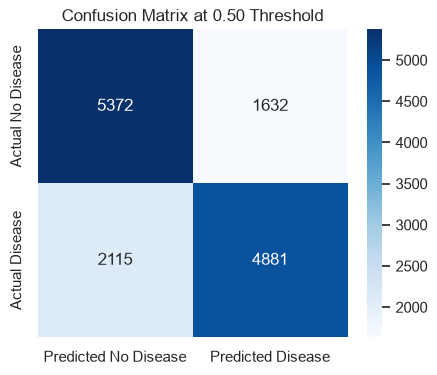

In [30]:
# Confusion matrix.
# Why: Healthcare stakeholders need to see missed cases and false alarms, not only average metrics.

cm = confusion_matrix(y_test, y_pred_default)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted No Disease", "Predicted Disease"],
    yticklabels=["Actual No Disease", "Actual Disease"],
)
plt.title("Confusion Matrix at 0.50 Threshold")
plt.xlabel("")
plt.ylabel("")
plt.show()

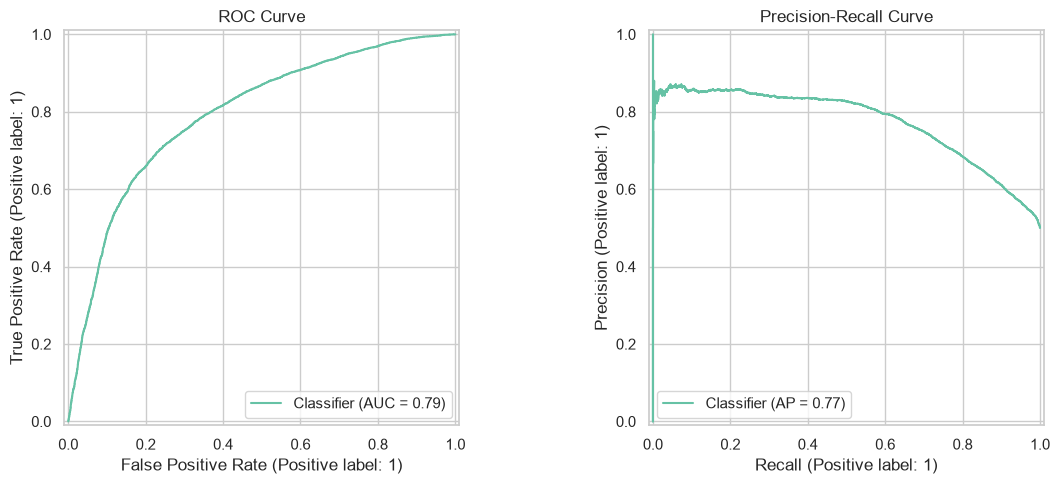

In [31]:
# ROC and precision-recall curves.
# Why: Curves show ranking performance and tradeoffs across thresholds.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0])
axes[0].set_title("ROC Curve")

PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()

,threshold,accuracy,precision,recall_sensitivity,specificity,f1,false_negative_rate,flagged_rate
0,0.200,0.593,0.553,0.965,0.221,0.703,0.035,0.872
1,0.250,0.634,0.584,0.930,0.338,0.717,0.070,0.796
2,0.300,0.669,0.616,0.894,0.444,0.729,0.106,0.724
3,0.350,0.696,0.649,0.853,0.539,0.737,0.147,0.657
4,0.400,0.716,0.685,0.799,0.633,0.738,0.201,0.583
5,0.450,0.727,0.717,0.748,0.705,0.732,0.252,0.521
6,0.500,0.732,0.749,0.698,0.767,0.723,0.302,0.465
7,0.550,0.729,0.771,0.652,0.807,0.707,0.348,0.423
8,0.600,0.722,0.794,0.599,0.845,0.683,0.401,0.377
9,0.650,0.712,0.814,0.549,0.875,0.656,0.451,0.337


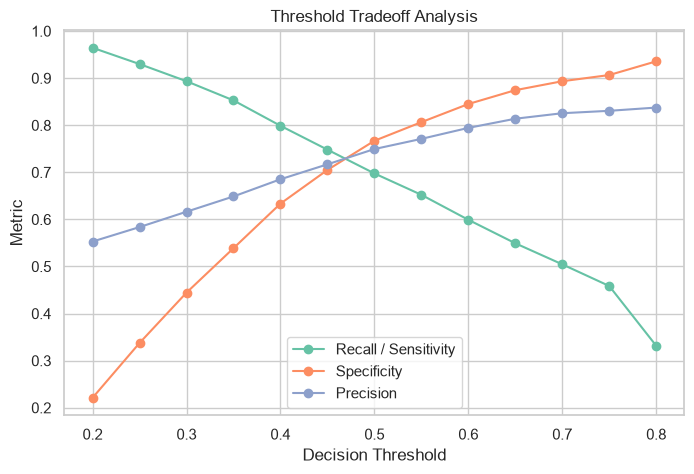

In [32]:
# Threshold analysis.
# Why: The default 0.50 threshold may not be appropriate for screening.

thresholds = np.arange(0.20, 0.81, 0.05)
threshold_rows = []

for threshold in thresholds:
    y_pred_threshold = (y_proba >= threshold).astype(int)
    metrics = evaluate_predictions(y_test, y_pred_threshold, y_proba)
    metrics["threshold"] = threshold
    metrics["flagged_rate"] = y_pred_threshold.mean()
    threshold_rows.append(metrics)

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df[[
    "threshold",
    "accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1",
    "false_negative_rate",
    "flagged_rate",
]])

plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["recall_sensitivity"], marker="o", label="Recall / Sensitivity")
plt.plot(threshold_df["threshold"], threshold_df["specificity"], marker="o", label="Specificity")
plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
plt.xlabel("Decision Threshold")
plt.ylabel("Metric")
plt.title("Threshold Tradeoff Analysis")
plt.legend()
plt.show()

In [33]:
# Choose a screening-oriented threshold.
# Why: A healthcare provider may accept more false positives to reduce missed disease cases.

MIN_RECALL_TARGET = 0.80

eligible_thresholds = threshold_df[threshold_df["recall_sensitivity"] >= MIN_RECALL_TARGET].copy()

if len(eligible_thresholds) > 0:
    selected_threshold = eligible_thresholds.sort_values("precision", ascending=False).iloc[0]["threshold"]
else:
    selected_threshold = threshold_df.sort_values("f1", ascending=False).iloc[0]["threshold"]

print(f"Selected threshold: {selected_threshold:.2f}")

y_pred_selected = (y_proba >= selected_threshold).astype(int)
selected_metrics = evaluate_predictions(y_test, y_pred_selected, y_proba)
display(selected_metrics.to_frame("selected_threshold_metric"))

Selected threshold: 0.35


,selected_threshold_metric
accuracy,0.696
precision,0.649
recall_sensitivity,0.853
specificity,0.539
f1,0.737
false_negative_rate,0.147
false_positive_rate,0.461
roc_auc,0.794


# Phase 8 - Model Interpretation
Model interpretation should answer:
Which factors matter most?
What is the model learning?
Why did the best model win?
What clinical or business actions might follow?
Where should the model not be used?
Interpretation should be cautious. Association in this dataset is not the same as causal proof.

In [34]:
# Get feature names after preprocessing.
# Why: Encoded feature names are needed for feature importance and model explanation.

def get_preprocessed_feature_names(fitted_pipeline):
    pre = fitted_pipeline.named_steps["preprocessor"]
    names = []

    for transformer_name, transformer, columns in pre.transformers_:
        if transformer_name == "remainder" and transformer == "drop":
            continue

        if transformer_name == "cat":
            onehot = transformer.named_steps["onehot"]
            encoded = onehot.get_feature_names_out(columns)
            names.extend(encoded.tolist())
        else:
            names.extend(list(columns))

    return names

feature_names = get_preprocessed_feature_names(best_model)
len(feature_names), feature_names[:10]

(68,
 ['age_years',
  'systolic_bp',
  'diastolic_bp',
  'height_cm',
  'weight_kg',
  'bmi',
  'lifestyle_risk_score',
  'clinical_risk_factor_count',
  'age_bp_interaction',
  'obesity_bp_interaction'])

,feature,importance
1,systolic_bp,0.221
41,bp_category_Hypertension Stage 2,0.117
2,diastolic_bp,0.073
0,age_years,0.072
8,age_bp_interaction,0.066
40,bp_category_Hypertension Stage 1,0.055
10,cholesterol_level,0.046
5,bmi,0.041
7,clinical_risk_factor_count,0.033
4,weight_kg,0.029


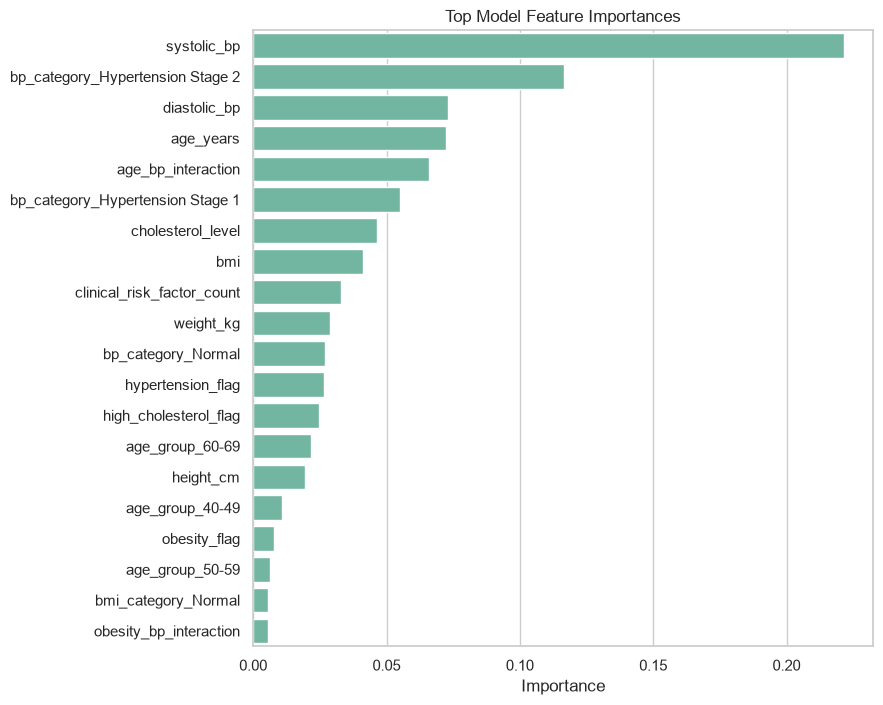

In [35]:
# Model-specific importance where available.
# Why: Tree models and linear models expose different kinds of importance.

fitted_estimator = best_model.named_steps["model"]

if hasattr(fitted_estimator, "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": fitted_estimator.feature_importances_,
    }).sort_values("importance", ascending=False)
    display(importance_df.head(25))

    plt.figure(figsize=(8, 8))
    sns.barplot(data=importance_df.head(20), y="feature", x="importance")
    plt.title("Top Model Feature Importances")
    plt.xlabel("Importance")
    plt.ylabel("")
    plt.show()

elif hasattr(fitted_estimator, "coef_"):
    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": fitted_estimator.coef_[0],
    })
    coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
    coef_df = coef_df.sort_values("abs_coefficient", ascending=False)
    display(coef_df.head(25))
else:
    print("This model does not expose native feature importance. Use permutation importance below.")

,feature,importance_mean,importance_std
1,systolic_bp,0.034,0.005
0,age_years,0.022,0.002
23,age_group,0.016,0.001
10,cholesterol_level,0.006,0.002
15,high_cholesterol_flag,0.004,0.001
5,bmi,0.003,0.001
19,inactive_flag,0.002,0.002
27,exam_month,0.002,0.001
8,age_bp_interaction,0.001,0.002
6,lifestyle_risk_score,0.001,0.000


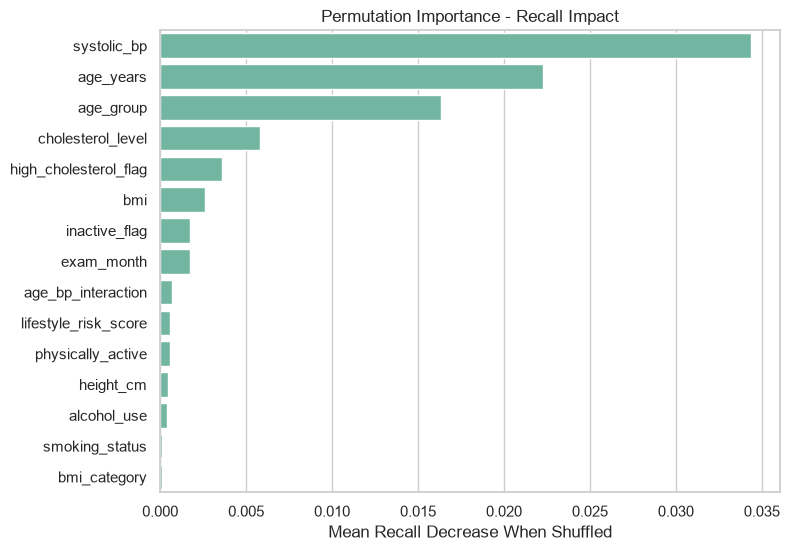

In [36]:
# Permutation importance.
# Why: Measures how much performance drops when a feature is shuffled, which works across many model types.

PERMUTATION_SAMPLE_SIZE = 5000
X_perm = X_test.sample(min(PERMUTATION_SAMPLE_SIZE, len(X_test)), random_state=RANDOM_STATE)
y_perm = y_test.loc[X_perm.index]

perm = permutation_importance(
    best_model,
    X_perm,
    y_perm,
    scoring="recall",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

perm_df = pd.DataFrame({
    "feature": X_perm.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

display(perm_df.head(20))

plt.figure(figsize=(8, 6))
sns.barplot(data=perm_df.head(15), y="feature", x="importance_mean")
plt.title("Permutation Importance - Recall Impact")
plt.xlabel("Mean Recall Decrease When Shuffled")
plt.ylabel("")
plt.show()

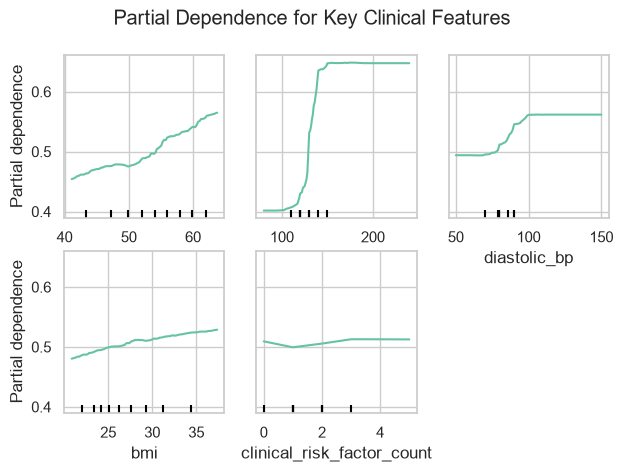

In [38]:
# Partial dependence for clinically important numeric variables.
# Why: Partial dependence shows how predicted risk changes as a feature changes, holding other features averaged.

features_to_plot = ["age_years", "systolic_bp", "diastolic_bp", "bmi", "clinical_risk_factor_count"]
available_features = [f for f in features_to_plot if f in X_test.columns]

X_pdp = X_test.sample(min(5000, len(X_test)), random_state=RANDOM_STATE).copy()
for feature in available_features:
    X_pdp[feature] = X_pdp[feature].astype(float)

PartialDependenceDisplay.from_estimator(
    best_model,
    X_pdp,
    features=available_features,
)
plt.suptitle("Partial Dependence for Key Clinical Features")
plt.tight_layout()
plt.show()

In [40]:
# Optional SHAP interpretation for tree-based models.
# Why: SHAP can explain global and local prediction drivers, but it may require extra setup.

if SHAP_AVAILABLE and hasattr(fitted_estimator, "feature_importances_"):
    X_shap_raw = X_test.sample(min(2000, len(X_test)), random_state=RANDOM_STATE)
    X_shap_transformed = best_model.named_steps["preprocessor"].transform(X_shap_raw)

    explainer = shap.TreeExplainer(fitted_estimator)
    shap_values = explainer.shap_values(X_shap_transformed)

    if isinstance(shap_values, list):
        shap_values_to_plot = shap_values[1]
    else:
        shap_values_to_plot = shap_values

    shap.summary_plot(shap_values_to_plot, X_shap_transformed, feature_names=feature_names, show=True)
else:
    print("SHAP is unavailable or the selected model is not tree-based. Permutation importance is sufficient for the portfolio.")

SHAP is unavailable or the selected model is not tree-based. Permutation importance is sufficient for the portfolio.


In [41]:
# Save final model artifact.
# Why: A professional project preserves the trained pipeline so it can be reused for scoring or demonstration.

import joblib

model_path = OUTPUT_DIR / "heart_disease_screening_model.joblib"
joblib.dump(best_model, model_path)

metrics_path = OUTPUT_DIR / "final_model_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(final_metrics.to_dict(), f, indent=2)

print(f"Saved model to: {model_path}")
print(f"Saved metrics to: {metrics_path}")

Saved model to: C:\Users\HP\Documents\Project 3 - Healthcare - Predictive Analytics\outputs\heart_disease_screening_model.joblib
Saved metrics to: C:\Users\HP\Documents\Project 3 - Healthcare - Predictive Analytics\outputs\final_model_metrics.json
